# Task 2 Exploratory Data Analysis

## Dataset Overview
- **Dataset:** Retail Store Sales (from Kaggle)
- **Rows:** 11,362 transactions (after cleaning in Task 1)
- **Columns:** 14 columns numerical (prices, quantities), categorical (product type, payment method), and dates


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('../01-data-wrangling/data/retail_store_sales_clean.csv')

print(f'Shape: {df.shape}')

df.head()

Shape: (11362, 14)


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Year,Month,Weekday
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10,185.0,Digital Wallet,Online,2024-04-08,True,2024,4,Monday
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9,261.0,Digital Wallet,Online,2023-07-23,True,2023,7,Sunday
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2,43.0,Credit Card,Online,2022-10-05,False,2022,10,Wednesday
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9,247.5,Credit Card,Online,2022-05-07,False,2022,5,Saturday
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7,87.5,Digital Wallet,Online,2022-10-02,False,2022,10,Sunday


### Column Info & Data Types

In [2]:
print('Column names:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

Column names:
['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied', 'Year', 'Month', 'Weekday']

Data types:
Transaction ID          str
Customer ID             str
Category                str
Item                    str
Price Per Unit      float64
Quantity              int64
Total Spent         float64
Payment Method          str
Location                str
Transaction Date        str
Discount Applied       bool
Year                  int64
Month                 int64
Weekday                 str
dtype: object


### Data Preparation Checks

In [3]:
sales_cols = ['Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Location', 'Payment Method']
df_sales = df[sales_cols]
print('Subset shape:', df_sales.shape)
df_sales.head()

Subset shape: (11362, 7)


,Category,Item,Price Per Unit,Quantity,Total Spent,Location,Payment Method
0,Patisserie,Item_10_PAT,18.5,10,185.0,Online,Digital Wallet
1,Milk Products,Item_17_MILK,29.0,9,261.0,Online,Digital Wallet
2,Butchers,Item_12_BUT,21.5,2,43.0,Online,Credit Card
3,Beverages,Item_16_BEV,27.5,9,247.5,Online,Credit Card
4,Food,Item_6_FOOD,12.5,7,87.5,Online,Digital Wallet


In [4]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
print('After conversion:')
print(df.dtypes)  # Transaction Date should now show as datetime64

After conversion:
Transaction ID                 str
Customer ID                    str
Category                       str
Item                           str
Price Per Unit             float64
Quantity                     int64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
Discount Applied              bool
Year                         int64
Month                        int64
Weekday                        str
dtype: object


In [5]:
print('Null values per column:')
print(df.isna().sum())

dup_count = df.duplicated().sum()
print(f'\nDuplicate rows: {dup_count}')

Null values per column:
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
Year                0
Month               0
Weekday             0
dtype: int64

Duplicate rows: 0


No nulls, no duplicates. Data is clean.

## Part 1: Descriptive Statistics

In [6]:
df.describe()

,Price Per Unit,Quantity,Total Spent,Transaction Date,Year,Month
count,11362.000000,11362.000000,11362.000000,11362,11362.000000,11362.000000
mean,23.356847,5.535029,129.642537,2023-07-12 21:04:20.447104,2023.042158,6.370709
min,5.000000,1.000000,5.000000,2022-01-01 00:00:00,2022.000000,1.000000
25%,14.000000,3.000000,52.000000,2022-09-29 00:00:00,2022.000000,3.000000
50%,23.000000,6.000000,108.500000,2023-07-13 00:00:00,2023.000000,6.000000
75%,33.500000,8.000000,192.000000,2024-04-25 00:00:00,2024.000000,9.000000
max,41.000000,10.000000,410.000000,2025-01-18 00:00:00,2025.000000,12.000000
std,10.736030,2.855166,94.662368,NaN,0.855290,3.498419


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11362 entries, 0 to 11361
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    11362 non-null  str           
 1   Customer ID       11362 non-null  str           
 2   Category          11362 non-null  str           
 3   Item              11362 non-null  str           
 4   Price Per Unit    11362 non-null  float64       
 5   Quantity          11362 non-null  int64         
 6   Total Spent       11362 non-null  float64       
 7   Payment Method    11362 non-null  str           
 8   Location          11362 non-null  str           
 9   Transaction Date  11362 non-null  datetime64[us]
 10  Discount Applied  11362 non-null  bool          
 11  Year              11362 non-null  int64         
 12  Month             11362 non-null  int64         
 13  Weekday           11362 non-null  str           
dtypes: bool(1), datetime64[us](1), fl

In [8]:
print('Nulls:', df.isnull().sum().to_dict())

Nulls: {'Transaction ID': 0, 'Customer ID': 0, 'Category': 0, 'Item': 0, 'Price Per Unit': 0, 'Quantity': 0, 'Total Spent': 0, 'Payment Method': 0, 'Location': 0, 'Transaction Date': 0, 'Discount Applied': 0, 'Year': 0, 'Month': 0, 'Weekday': 0}


**Key stats:** Avg Total Spent = $129.64, Median = $108.50. Right-skewed.
Prices range $5–$41. Quantities 1–10. Data spans Jan 2022 – Jan 2025.

### Looking at Each Category Column

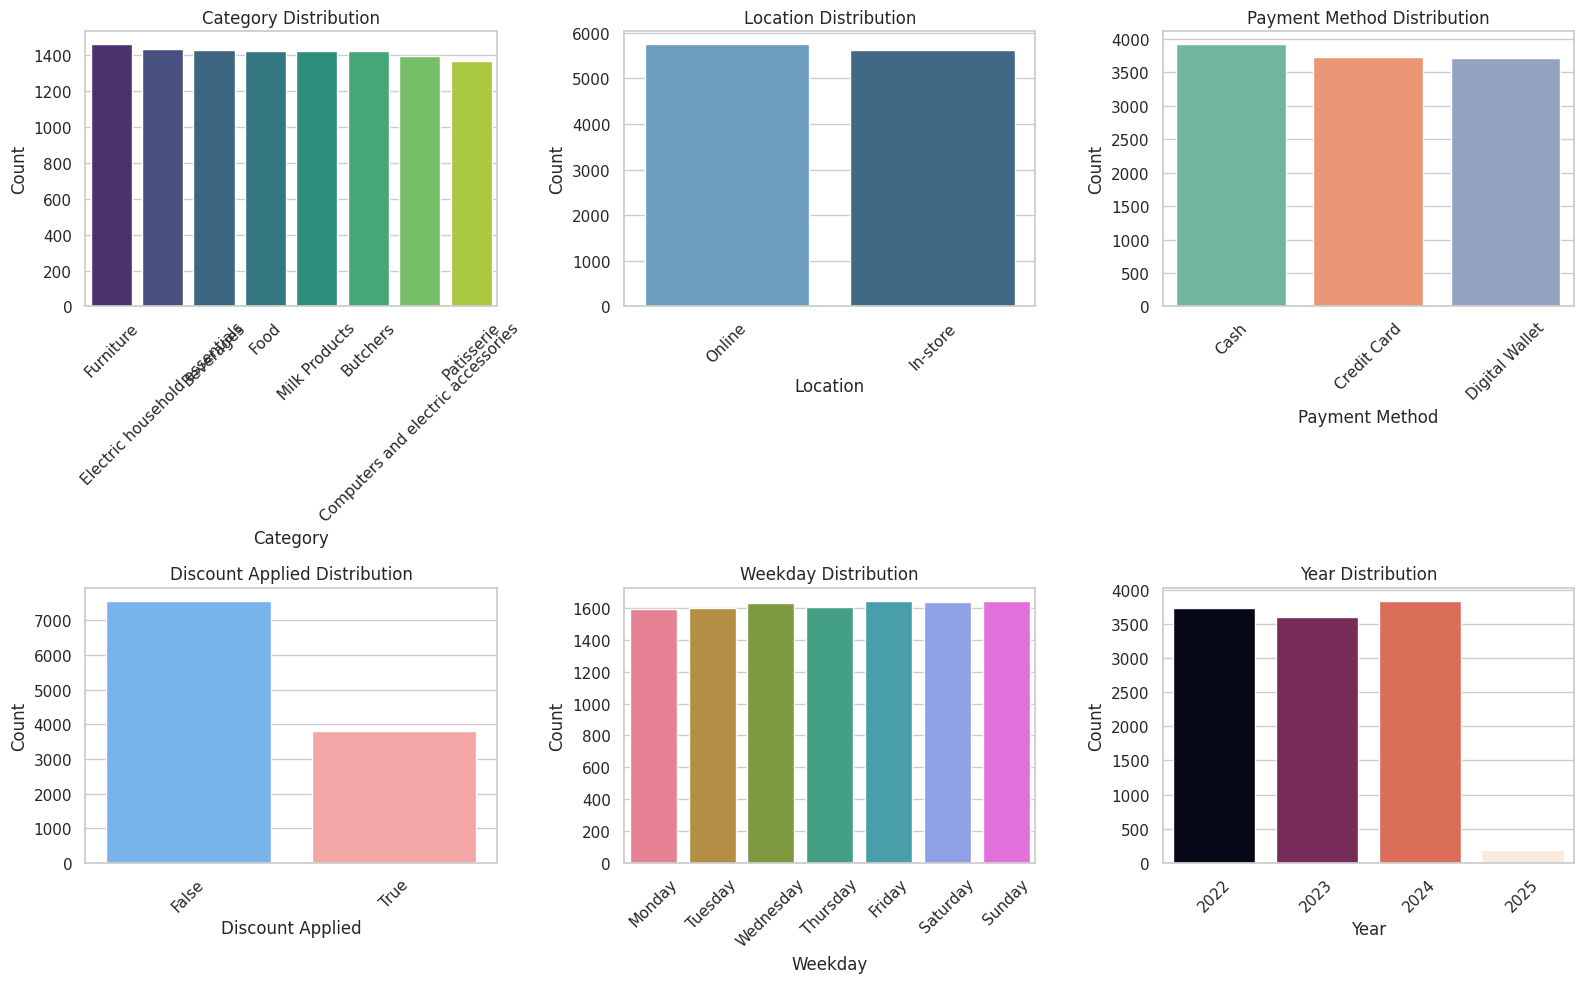

In [9]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

cat_cols = ['Category', 'Location', 'Payment Method', 'Discount Applied', 'Weekday', 'Year']

for ax, col in zip(axes.flat, cat_cols):
    if col == 'Weekday':
        order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
        vals = df[col].value_counts().reindex(order).reset_index()
        vals.columns = [col, 'count']
        sns.barplot(data=vals, x=col, y='count', hue=col, palette='husl', ax=ax, legend=False)
    
    elif col == 'Discount Applied':
        vals = df[col].value_counts().reset_index()
        vals.columns = [col, 'count']
        sns.barplot(data=vals, x=col, y='count', hue=col, palette=['#66b3ff','#ff9999'], ax=ax, legend=False)
    
    elif col == 'Location':
        vals = df[col].value_counts().reset_index()
        vals.columns = [col, 'count']
        sns.barplot(data=vals, x=col, y='count', hue=col, palette='Blues_d', ax=ax, legend=False)
    
    elif col == 'Payment Method':
        vals = df[col].value_counts().reset_index()
        vals.columns = [col, 'count']
        sns.barplot(data=vals, x=col, y='count', hue=col, palette='Set2', ax=ax, legend=False)
    
    elif col == 'Year':
        vals = df[col].value_counts().sort_index().reset_index()
        vals.columns = [col, 'count']
        sns.barplot(data=vals, x=col, y='count', hue=col, palette='rocket', ax=ax, legend=False)
    
    else:
        vals = df[col].value_counts().reset_index()
        vals.columns = [col, 'count']
        sns.barplot(data=vals, x=col, y='count', hue=col, palette='viridis', ax=ax, legend=False)
    
    ax.set_title(f'{col} Distribution')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)  # rotating labels so they don't overlap

plt.tight_layout()  # auto-adjust spacing
plt.show()

**Observations:** All 8 categories nearly equal (~1,400 txns each). Online 50.9%. Cash most used. ~33.5% discounted. Weekdays similar. 2024 busiest.

### Looking at the Number Columns

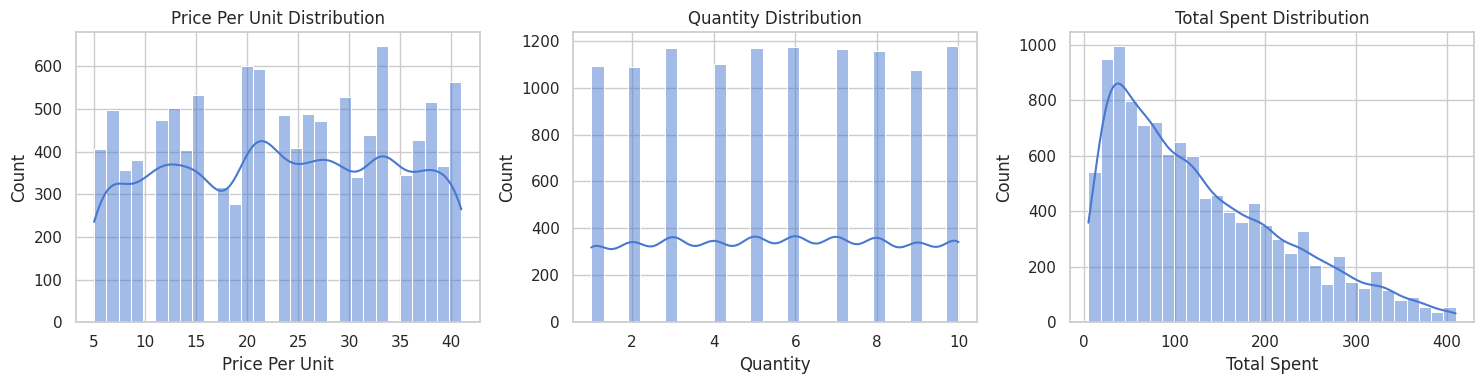

In [10]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
num_cols = ['Price Per Unit', 'Quantity', 'Total Spent']

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

**Price:** Evenly spread $5–$41. **Quantity:** Peaks at 1 and 10.
**Total Spent:** Right-skewed, most under $200, some up to $410.

## Part 2: Looking at Relationships Between Variables

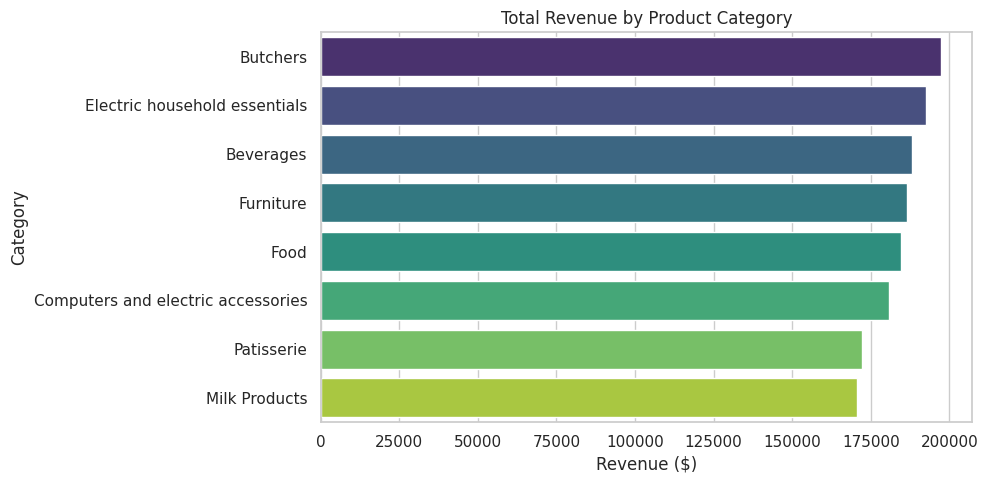

In [11]:

cat_rev = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(x=cat_rev.values, y=cat_rev.index, hue=cat_rev.index, palette='viridis', ax=ax, legend=False)
ax.set_title('Total Revenue by Product Category')
ax.set_xlabel('Revenue ($)')
plt.tight_layout()
plt.show()

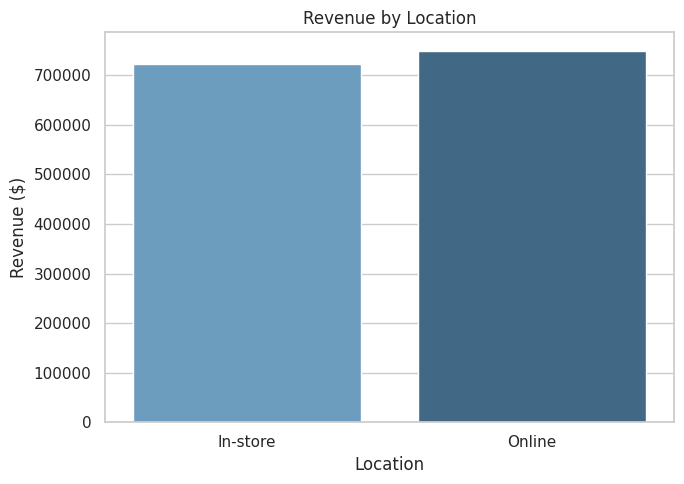

In [12]:
loc_rev = df.groupby('Location')['Total Spent'].sum()

fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(x=loc_rev.index, y=loc_rev.values, hue=loc_rev.index, palette='Blues_d', ax=ax, legend=False)
ax.set_title('Revenue by Location')
ax.set_ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

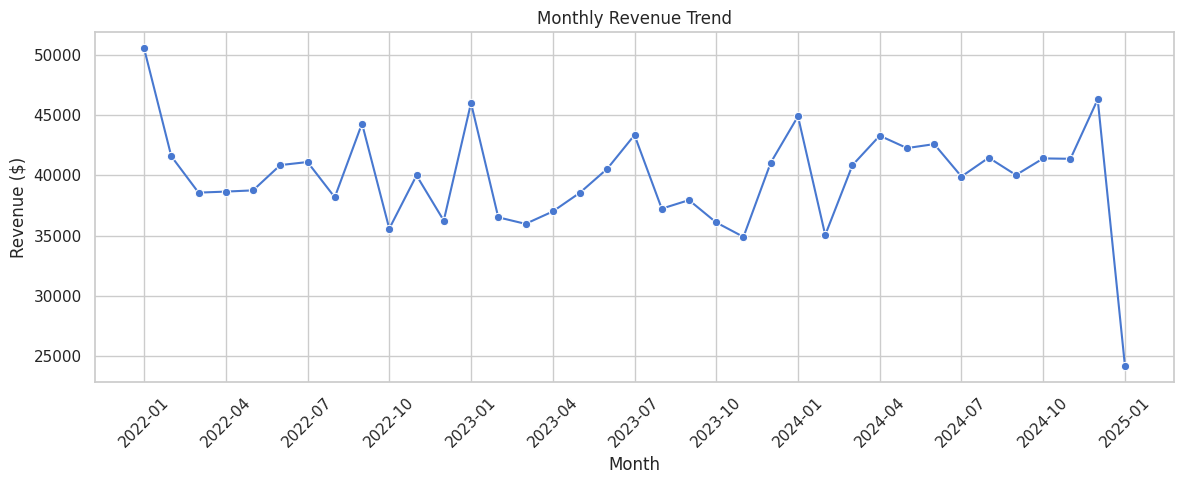

In [13]:

monthly = df.groupby(['Year','Month'])['Total Spent'].sum().reset_index()

monthly['ym'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(x=range(len(monthly)), y='Total Spent', data=monthly, marker='o', ax=ax)

ax.set_xticks(range(0,len(monthly),3))
ax.set_xticklabels(monthly['ym'].iloc[::3], rotation=45)
ax.set_title('Monthly Revenue Trend')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

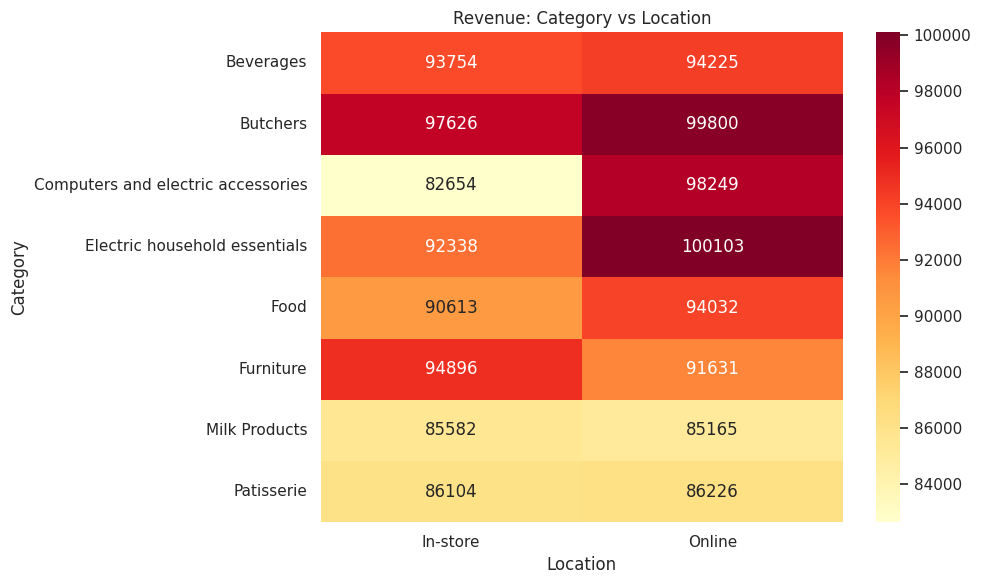

In [14]:

ct = pd.crosstab(df['Category'], df['Location'], values=df['Total Spent'], aggfunc='sum')

fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(ct, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_title('Revenue: Category vs Location')
plt.tight_layout()
plt.show()

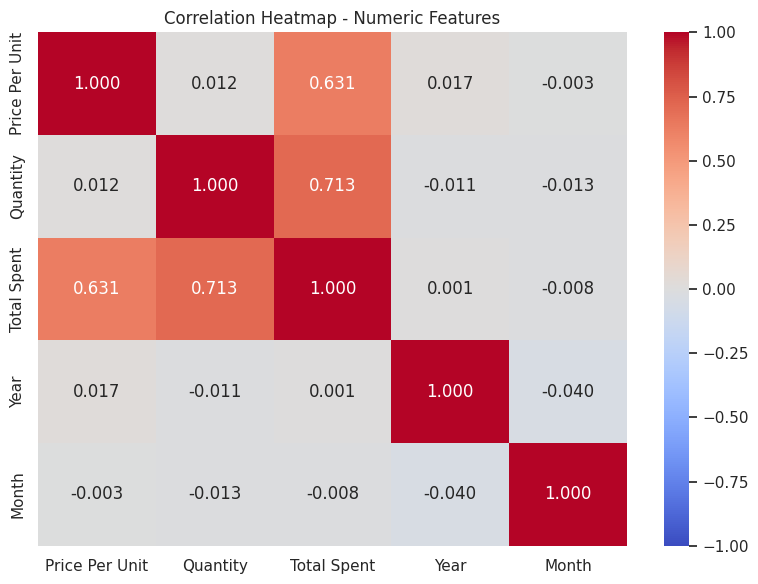

In [15]:

corr = df[['Price Per Unit','Quantity','Total Spent','Year','Month']].corr()

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax, fmt='.3f')
ax.set_title('Correlation Heatmap - Numeric Features')
plt.tight_layout()
plt.show()

### Standalone Scatter Plot

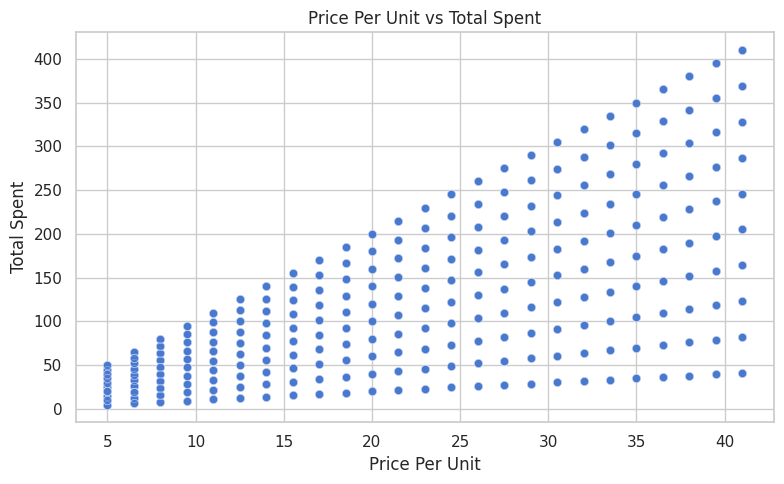

In [16]:

fig, ax = plt.subplots(figsize=(8,5))
sns.scatterplot(data=df, x='Price Per Unit', y='Total Spent', alpha=0.3, ax=ax)
ax.set_title('Price Per Unit vs Total Spent')
plt.tight_layout()
plt.show()

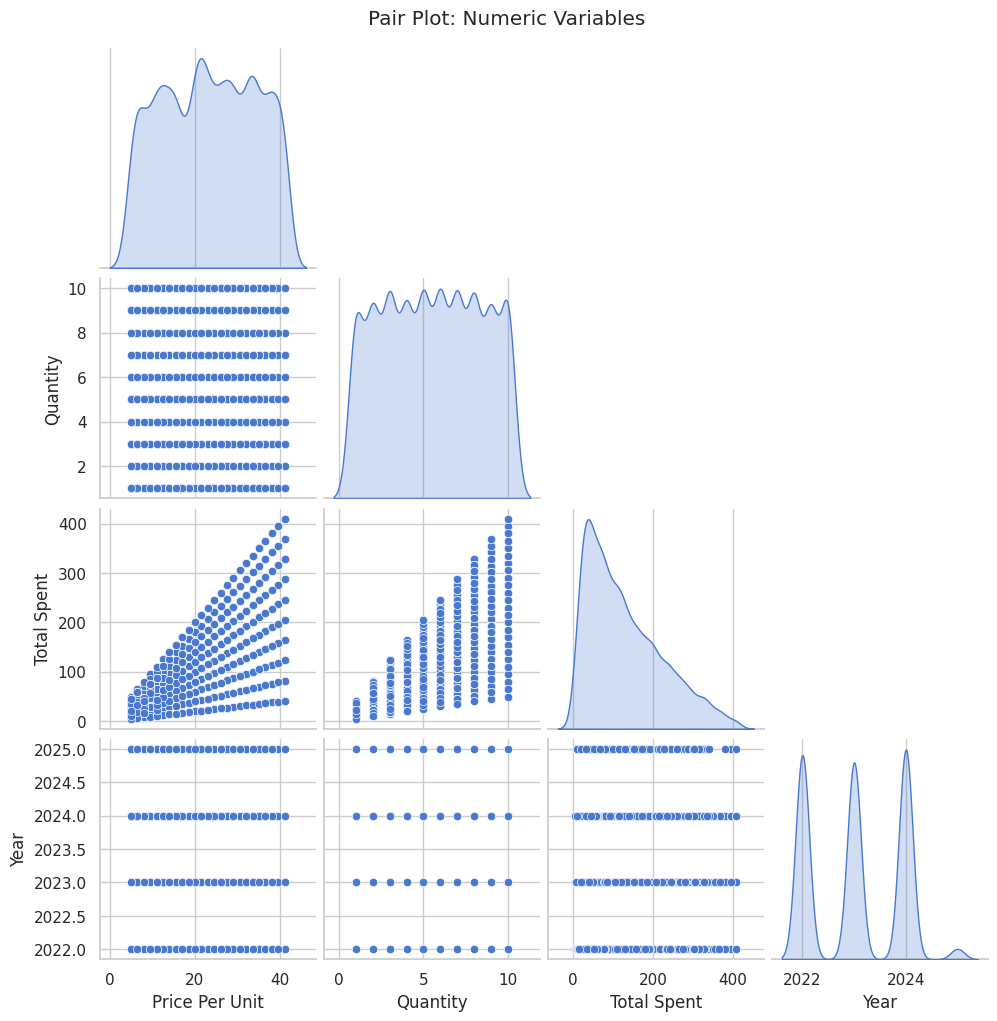

In [17]:

fig = sns.pairplot(df[['Price Per Unit','Quantity','Total Spent','Year']], 
                   diag_kind='kde', corner=True)
fig.fig.suptitle('Pair Plot: Numeric Variables', y=1.02)
plt.show()

/tmp/ipykernel_1552759/2271552560.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


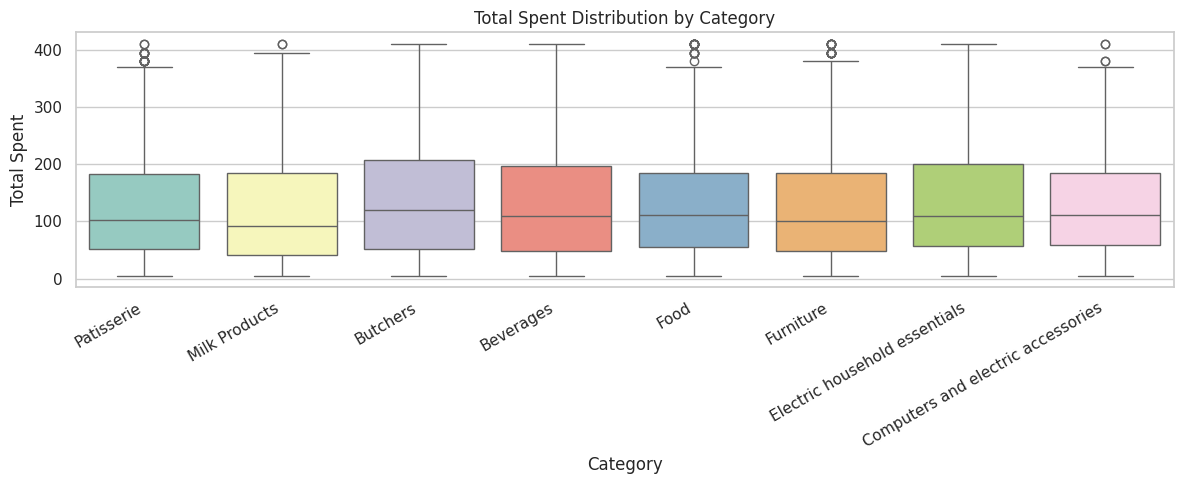

In [18]:

fig, ax = plt.subplots(figsize=(12,5))
sns.boxplot(x='Category', y='Total Spent', data=df, hue='Category', palette='Set3', ax=ax, legend=False)
ax.set_title('Total Spent Distribution by Category')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Key Insights from Charts

- **Butchers** top revenue at 97K; Electric Household close 2nd at 92K
- **Online vs In-store** balanced (50.9% / 49.1%)
- **Revenue** stable month-to-month, no strong seasonality
- **Discounts** DON'T reduce AOV (30.72 discounted vs 29.10 non-discounted)
- **Top product:** Item_25_FUR (Furniture) at 5,256

## Part 3: Breaking Down Revenue by Different Angles

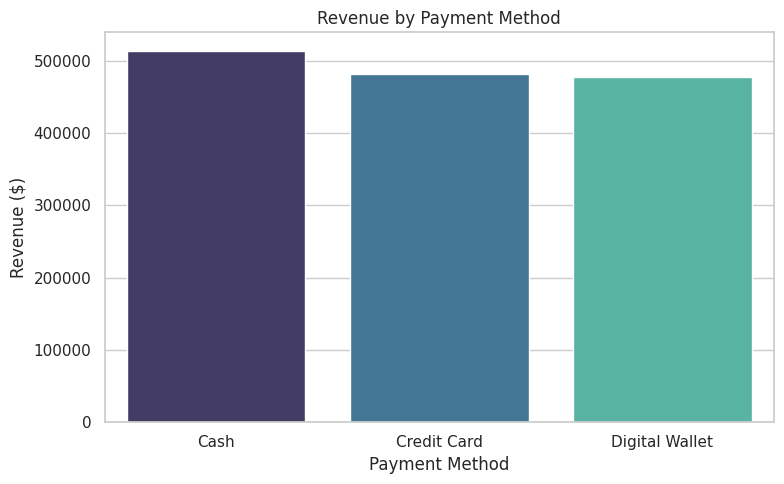

In [19]:
pm_rev = df.groupby('Payment Method')['Total Spent'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(x=pm_rev.index, y=pm_rev.values, hue=pm_rev.index, palette='mako', ax=ax, legend=False)
ax.set_title('Revenue by Payment Method')
ax.set_ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

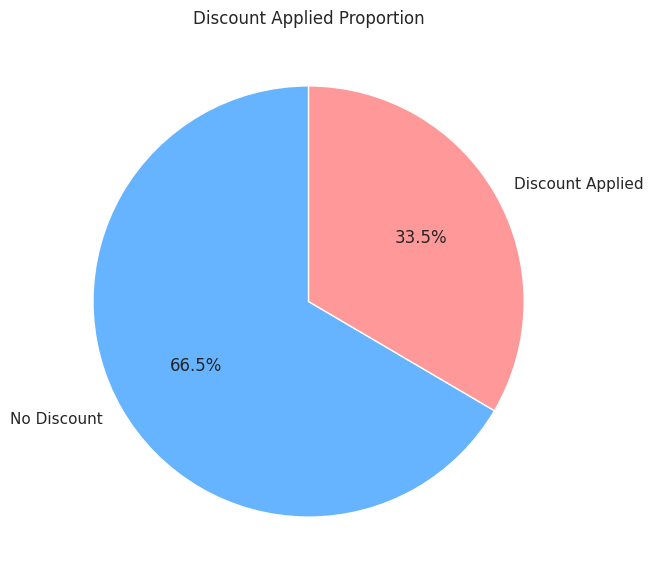

In [20]:

fig, ax = plt.subplots(figsize=(7,7))
disc = df['Discount Applied'].value_counts()
ax.pie(disc.values, labels=['No Discount','Discount Applied'], autopct='%1.1f%%',
       startangle=90, colors=['#66b3ff','#ff9999'])
ax.set_title('Discount Applied Proportion')
plt.show()

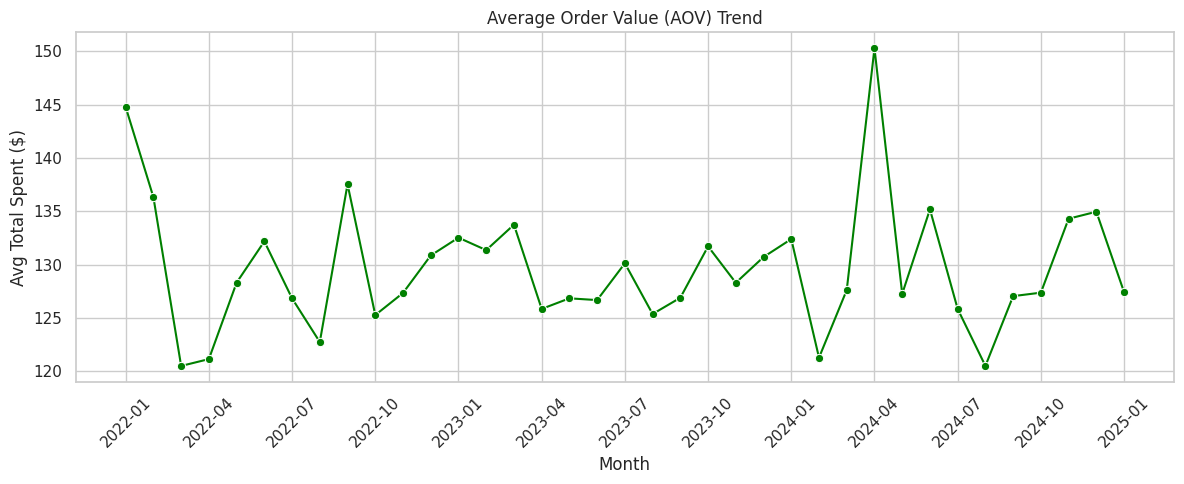

In [21]:

aov_monthly = df.groupby(['Year','Month'])['Total Spent'].mean().reset_index()
aov_monthly['ym'] = aov_monthly['Year'].astype(str) + '-' + aov_monthly['Month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(x=range(len(aov_monthly)), y='Total Spent', data=aov_monthly, marker='o', color='green', ax=ax)
ax.set_xticks(range(0,len(aov_monthly),3))
ax.set_xticklabels(aov_monthly['ym'].iloc[::3], rotation=45)
ax.set_title('Average Order Value (AOV) Trend')
ax.set_ylabel('Avg Total Spent ($)')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

In [22]:
print(df.groupby(['Category','Location'])['Total Spent'].sum().unstack())

Location                            In-store    Online
Category                                              
Beverages                            93753.5   94225.0
Butchers                             97626.0   99800.0
Computers and electric accessories   82653.5   98249.0
Electric household essentials        92338.5  100103.0
Food                                 90613.0   94032.0
Furniture                            94896.0   91631.0
Milk Products                        85582.5   85165.0
Patisserie                           86104.5   86226.0


### Revenue Breakdown

Cash leads revenue (14K) but all 3 methods close. 33.5% of txns discounted. AOV stays 25-35. Computers stronger online; Furniture stronger in-store.

## Part 4: SQL Business Queries

Wrote 10 SQL queries (Q1–Q10) against PostgreSQL covering: revenue by category, by location, by payment, monthly trends, AOV, discount impact, top products, and channel performance.

## 5. Summary

| Metric | Finding | Implication |
|---|---|---|
| Best Category | Butchers = $197K | Stock up on Butchers |
| Online vs Store | 50.9% / 49.1% | Both channels equal |
| Payments | All 3 close | No change needed |
| Discounts | 33.5% used, AOV same | Volume without margin hit |
| Busiest | Fri-Sun | Weekend promotions |
| Seasonality | Stable, Jan/Jul peaks | Plan promos around those |
| AOV | $125–$135 always | Consistent spending |

## 6. Proposed KPIs for Dashboard

1. Total Revenue
2. Average Order Value
3. Revenue by Category
4. Online vs In-store Share
5. Discount Rate
6. Monthly Revenue Trend
7. Top Products
8. Payment Method Mix